# **Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# statistics tool
from scipy.sparse import hstack

# preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold
)

# bagging model
from sklearn.ensemble import RandomForestRegressor

# metrics score
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer,
    mean_pinball_loss
)

# boosting model
from xgboost import XGBRegressor


pd.set_option('display.max_rows', None)


Previously, the file **Explanatory Data Analysis idx** explore our cleaned housing data market with making couple new features that were grouped into reasonable categories or into others.

We download the dataset called **cleaned_data_eda** csv file.

The primary research goal is to develop and evaluate a machine-learning model that can accurately predict a property’s closing price based on its physical characteristics, location, nearby amenities, and market conditions.



# **Data**

In [ ]:
# call csv dataset
df=pd.read_csv('/content/cleaned_data_eda.csv')
print(df.shape)
df.head()

(47549, 31)


,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,...,CPI,Age,LotDensity,FlooringType,SchoolDistrict,AgeGroup,CountyOrParish2,FlooringType2,SchoolCount2Miles,SchoolCountGroup
0,1,0,890000.0,34.180411,-118.342020,1434.0,Los Angeles,0,1,1.0,...,315.605,86.0,4.513947,Unknown,Burbank Unified,70+,Los Angeles,Unknown,21.0,20+ Schools
1,0,0,1138000.0,32.574359,-117.023836,2872.0,San Diego,1,6,3.0,...,315.605,25.0,1.817201,Unknown,Unknown,21-40,San Diego,Unknown,12.0,11-20 Schools
2,1,0,681877.0,33.725080,-117.222302,2824.0,Riverside,1,2,3.0,...,315.605,2.0,2.478754,Unknown,Unknown,0-5,Riverside,Unknown,2.0,1-5 Schools
3,1,0,900000.0,34.203479,-118.643567,2500.0,Los Angeles,1,2,3.0,...,315.605,55.0,3.334400,Unknown,Los Angeles Unified,41-70,Los Angeles,Unknown,12.0,11-20 Schools
4,0,0,862000.0,34.460368,-118.490755,2363.0,Los Angeles,1,2,3.0,...,315.605,31.0,4.953449,Unknown,Unknown,21-40,Los Angeles,Unknown,4.0,1-5 Schools


Let's identify what data features of data types.

In [ ]:
# show all features of data types
df.dtypes

,0
ViewYN,int64
PoolPrivateYN,int64
ClosePrice,float64
Latitude,float64
Longitude,float64
LivingArea,float64
CountyOrParish,object
AttachedGarageYN,int64
ParkingTotal,int64
BathroomsTotalInteger,float64



We will identify any missing values in this dataset.

In [ ]:
# check explicit missing values
df.isna().sum()

,0
ViewYN,0
PoolPrivateYN,0
ClosePrice,0
Latitude,0
Longitude,0
LivingArea,0
CountyOrParish,0
AttachedGarageYN,0
ParkingTotal,0
BathroomsTotalInteger,0


We will exclude the features of **SchoolDistrict, Flooringtype, City, and CountyOrParish**. Instead, we will use **FlooringType2** and **CountyOrParish2** that contained "Others" that were grouped rare values in previous file of **Data Explanatory Analysis idx**.

In [ ]:
# split features by data types

continuous= [
    "Age",
    "CPI",
    "FedInterestRate",
    "Latitude",
    "LivingArea",
    "Longitude",
    "LotDensity",
    "LotSizeSquareFeet",
    "MortgageRate30Fixed",
    "SalesTaxRate",
    "UnemploymentRate"
]

discrete= [
    "BathroomsTotalInteger",
    "BedroomsTotal",
    "Stories",
    "GarageSpaces",
    "ParkingTotal",
    "SchoolCount2Miles"
]

categorical = [
    "CountyOrParish2",
    "FlooringType2",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN"

]



Let's divide into independent and dependent features with producing training and testing dataset.

In [ ]:
# split features into independent and dependent variable
X = df.drop(columns = ["ClosePrice"])

y = df["ClosePrice"]

# construct training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

We need to encode for categorical and ordinal variables using preprocessing library from scikit-learn package. For the tree models, standard scaler for continuous numercial variable is not required for this stage.

In [ ]:

X_train_num = X_train[continuous + discrete].to_numpy()
X_test_num = X_test[continuous + discrete].to_numpy()

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop="first")
X_train_cate_encode = encoder.fit_transform(X_train[categorical])
X_test_cate_encode = encoder.transform(X_test[categorical])

X_train_processed = hstack([X_train_num, X_train_cate_encode])
X_test_processed = hstack([X_test_num, X_test_cate_encode])




In [ ]:
# show dimension of independent variable set
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (38039, 49)
Test shape: (9510, 49)


# **Feature Importance**

We will identify the feature importance that calculated using a Random Forest Regressor with $300$ decision trees. The importance scores indicate how much each feature contributed to reducing prediction error across the trees, with higher scores representing greater influence on the predicted close price.

In [ ]:
# set random forest regressor
model = RandomForestRegressor(n_estimators=300, random_state=48, n_jobs=-1)

model.fit(X_train_processed, y_train)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=48)

In [ ]:
# call out feature names
feature_names = np.concatenate([
    continuous + discrete,
    encoder.get_feature_names_out(categorical)
])

# dataframe for feature importance
df_importance = pd.DataFrame(
    {
     "feature": feature_names,
     "importance": model.feature_importances_
  }
).sort_values(
    by = "importance",
    ascending=False
).reset_index(drop = True)

df_importance

,feature,importance
0,LivingArea,0.195884
1,Latitude,0.175941
2,BathroomsTotalInteger,0.173981
3,Longitude,0.143247
4,SalesTaxRate,0.059759
5,CountyOrParish2_Orange,0.047173
6,Age,0.044094
7,SchoolCount2Miles,0.027536
8,LotSizeSquareFeet,0.021732
9,LotDensity,0.015535


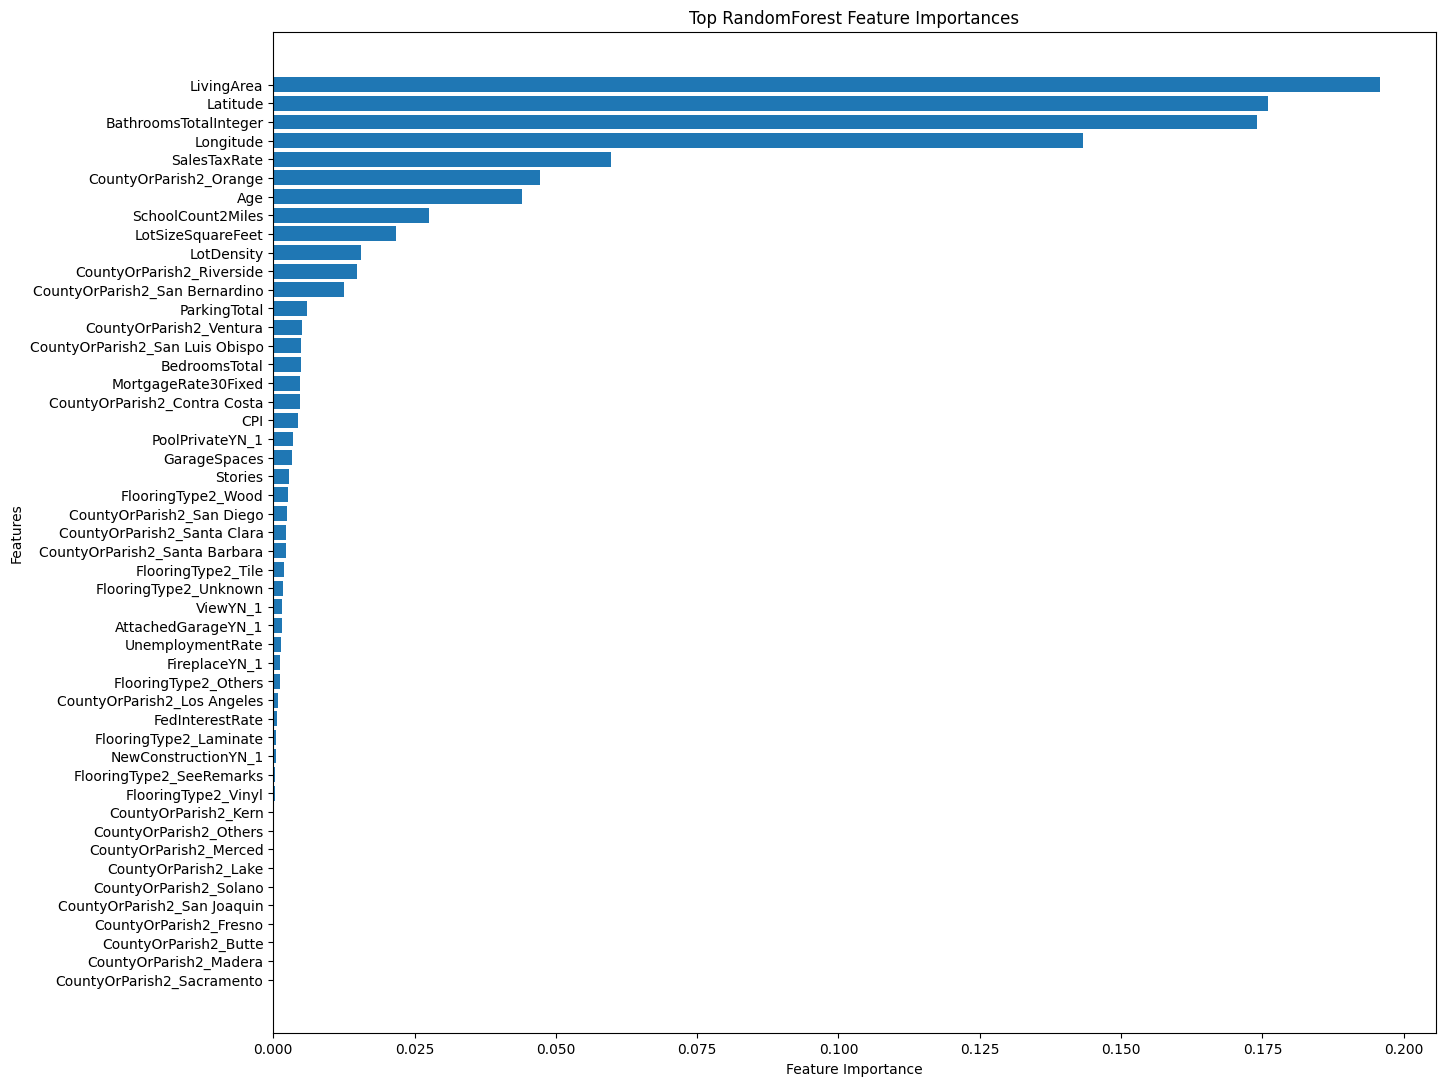

In [ ]:
# barchart for feature importance result
plt.figure(figsize = (15, 13))
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top RandomForest Feature Importances")
plt.show()



The feature importance result indicates that

- **Living area** is the strongest predictor of close price with $19.6\%$, **Latitude** $17.6\%$, **BathroomsTotalInteger** $17.4\%$, and **Longitude** $14.3\%$.

- **Those features account for approximately $68.9\%$ indicating that property size, bathroom count, and geographic location were the main factors**

- **SalesTaxRate** and the **Orange County** indicator also had noticeable importance, while features such as **age, nearby school count, lot size, and lot density** had smaller but still meaningful contributions.

# **Bagging Model**

We will construct bagging model of random forest regressor to predict the close price of California housing market sold during Dec 2024 to May 2025.

- Grid Search for hyperparameter tuning to find optimal settings for random forest regressor.

- In each stage, only one group of related parameters was tuned, while the remaining parameters were temporarily held constant at reasonable baseline values or at the best values identified in earlier stages. The best parameters from each stage were then carried forward to the next stage.

- Specifically, tree-complexity parameters were tuned first, followed by row and feature sampling parameters, the number of trees, and finally the maximum number of leaf nodes if additional regularization was needed.

- Focus on mean absolute percentage error due to close price of huge with greater than 0 values.




In [ ]:
# helper function to print cross-validation results
def metric_scores(grid, metric):
    cv_results = grid.cv_results_
    best_index = grid.best_index_

    mean_score = cv_results[f"mean_test_{metric}"][best_index]
    std_score = cv_results[f"std_test_{metric}"][best_index]
    print(f"CV {metric} (mean +- std): {mean_score:.3f} +- {std_score:.3f}")

scoring = {
    "MAPE": "neg_mean_absolute_percentage_error",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [ ]:
# set random forest with default values for consistency while tuning
model_rf = RandomForestRegressor(
    n_estimators=300,
    max_features=1.0,


    max_samples=None,
    max_leaf_nodes=None,

    criterion="squared_error",
    random_state=48,
    n_jobs=-1

)

We will tune the tree complexity first because they directly control model flexibility and risk of overfitting.

- **max_depth** : The maximum number of levels a tree can grow.

- **min_samples_split** : The minimum number of observations required in a node before node can split.

- **min_samples_leaf** : The minimum number of observations that must remain in each final leaf.

In [ ]:
# set tree complexity parameters
param = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

In [ ]:
# construct grid search of validation set
grid = GridSearchCV(
    model_rf,
    param_grid = param,
    cv=3,
    scoring = scoring,
    n_jobs=-1,
    refit = "MAPE",
    return_train_score = True
)


grid.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                             random_state=48),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show the result of tuning hyper parameter
cv_results = pd.DataFrame(grid.cv_results_)

cv_results = (
    cv_results[
        [
          "param_max_depth",
          "param_min_samples_split",
          "param_min_samples_leaf",
          "mean_test_MAPE",
          "mean_test_RMSE",
          "mean_test_MAE",
          "mean_test_R2",
          "mean_train_R2",
          "mean_fit_time"
        ]
    ].sort_values(by = "mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# list of negative values
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

# change those negative value to positive
cv_results[neg_metrics] = cv_results[neg_metrics].abs()

cv_results


,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,None,2,2,0.125762,273533.362843,140966.839603,0.849262,0.967087,801.081035
1,None,5,2,0.125947,273704.600926,141151.427348,0.849072,0.963605,704.572108
2,None,2,1,0.126120,272581.785459,140841.057864,0.850306,0.979795,1617.598750
3,None,5,1,0.126422,273344.574030,141243.598987,0.849466,0.971023,766.342814
4,20,2,2,0.127492,273642.844603,141773.682125,0.849143,0.965494,675.739568
5,None,10,2,0.127551,276460.648348,142846.436471,0.846021,0.945218,540.903714
6,20,5,2,0.127670,274109.444718,142025.656268,0.848628,0.962076,605.707123
7,20,2,1,0.127933,273036.705438,141797.972691,0.849808,0.977549,1134.140961
8,None,10,1,0.127984,276090.910684,142941.898433,0.846430,0.952690,568.531924
9,20,5,1,0.128380,273805.363887,142260.189292,0.848962,0.969028,622.807642


In [ ]:
grid.best_params_

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

The best validation set performance is follwing:

- **The no limitation of tree depth until another stopping rule is reached, final leaf must contain at least two training observation, node considered for splitting when it contains at least two observation**, show the best parameter values

- minimal samples leaf and split depends on the max depth tree performance.

- Restricting the trees to depths $5$ or $10$ is substantial underftting that mean absolute percentage error were better after $20$ and None depth.

- Model’s predictions differed from actual close prices by about **$12.58\%$** on average, with an average absolute dollar error of about **$\$140,967$**. The model explained approximately **$84.9\%$** of the variation in close prices in the validation folds.

Now let's identify row and feature sampling tuning.

- max_samples : Proportion of training observations randomly sampled in each tree.

- max_features : How many features are randomly considered in each split.

In [ ]:
# constrcut random foreest with previous best parameter
model_rf = RandomForestRegressor(
    n_estimators=300,

    max_depth = grid.best_params_["max_depth"],
    min_samples_split = grid.best_params_["min_samples_split"],
    min_samples_leaf = grid.best_params_["min_samples_leaf"],

    criterion="squared_error",
    max_leaf_nodes=None,

    random_state=48,
    n_jobs=-1

)

In [ ]:
# new hyper parameter
param = {
    "max_samples": [0.7, 0.9, None],
    "max_features": [0.5, 0.7, 1.0, "sqrt"]
}

In [ ]:
# construct grid search with validation set
grid_2 = GridSearchCV(
    model_rf,
    param_grid = param,
    cv=3,
    scoring = scoring,
    n_jobs=-1,
    refit = "MAPE",
    return_train_score = True
)
grid_2.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestRegressor(min_samples_leaf=2,
                                             n_estimators=300, n_jobs=-1,
                                             random_state=48),
             n_jobs=-1,
             param_grid={'max_features': [0.5, 0.7, 1.0, 'sqrt'],
                         'max_samples': [0.7, 0.9, None]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show the results of tuning hyper parameter
cv_results = pd.DataFrame(grid_2.cv_results_)

cv_results = (
    cv_results[
        [
            "param_max_samples",
            "param_max_features",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# show negative values list
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

# convert to positive
cv_results[neg_metrics] = cv_results[neg_metrics].abs()

cv_results

,param_max_samples,param_max_features,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,None,1.0,0.125762,273533.362843,140966.839603,0.849262,0.967087,766.352517
1,0.9,1.0,0.126259,274162.659902,141431.507445,0.848569,0.962383,724.014751
2,None,0.7,0.127484,277023.531991,142719.386643,0.845407,0.964463,561.910892
3,0.7,1.0,0.128157,277494.256694,143466.408044,0.844872,0.949412,611.871960
4,0.9,0.7,0.128321,278327.470478,143515.411415,0.843950,0.959557,518.747263
5,0.7,0.7,0.130578,281887.411884,145677.809791,0.839922,0.945940,430.077275
6,None,0.5,0.131842,283566.559846,146750.682041,0.838028,0.960786,417.412249
7,0.9,0.5,0.132715,285233.587853,147605.699504,0.836122,0.955307,391.569037
8,0.7,0.5,0.135495,289739.891558,150383.592865,0.830905,0.940586,317.253832
9,None,sqrt,0.167602,329424.497158,178548.103195,0.781431,0.925194,126.746624


In [ ]:
# extract the best parameters what we used
grid_2.best_params_

{'max_features': 1.0, 'max_samples': None}

- **The best parameter is using all the training observation, and all the features for validation set**.

- Model’s predictions differed from actual close prices by about **$12.58\%$** on average, with an average absolute dollar error of about **$\$140,967$**. The model explained approximately **$84.9\%$** of the variation in close prices in the validation folds.

Let's tune the forest size, the number of trees as **n_estimator**

In [ ]:
# construct random forest
model_rf = RandomForestRegressor(

    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 2,

    max_samples = None,
    max_features = 1.0,

    criterion="squared_error",
    max_leaf_nodes=None,

    random_state=48,
    n_jobs=1

)

In [ ]:
# hypeer-parameter
param = {

    "n_estimators": [300, 500, 700]
}


In [ ]:
# construct grid search with validation set
grid_3 = GridSearchCV(
    model_rf,
    param_grid = param,
    cv=3,
    scoring = scoring,
    n_jobs=-1,
    refit = "MAPE",
    return_train_score = True
)
grid_3.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=RandomForestRegressor(min_samples_leaf=2,
                                             n_estimators=300, n_jobs=1,
                                             random_state=48),
             n_jobs=-1, param_grid={'n_estimators': [300, 500, 700]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show tuning results of n_estimator
cv_results = pd.DataFrame(grid_3.cv_results_)

cv_results = (
    cv_results[
        [
            "param_n_estimators",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_train_R2",
            "mean_test_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# list of negative values
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

# convert to postive
cv_results[neg_metrics] = cv_results[neg_metrics].abs()

cv_results

,param_n_estimators,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_train_R2,mean_test_R2,mean_fit_time
0,700,0.125744,273473.119869,140932.452806,0.967295,0.849324,1537.360992
1,300,0.125762,273533.362843,140966.839603,0.967087,0.849262,726.318740
2,500,0.125792,273565.873938,141014.999654,0.967245,0.849223,1207.103611


- The $700$ trees shows the best parameter value in this stage.


- slightly better result, the best **test $R^2$ fit is about $84.93\%$ and mean absolute percentage error is about $12.57\%$, which it is pretty strong.**

- **The validation result shows some overfitting from the result training R^2 of $96.73\%$ and test of $84.93\%$ that difference presents $11.8\%$ gaps**, because the model used None values from max depth and max samples. This means trees go deeply without limitation.


## Evaluation

In [ ]:
# construct random forest
model_rf = RandomForestRegressor(
    n_estimators=700,

    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 2,

    max_samples = None,
    max_features = 1.0,

    criterion="squared_error",
    max_leaf_nodes=None,

    random_state=48,
    n_jobs=1

)

model_rf.fit(X_train_processed, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=700, n_jobs=1,
                      random_state=48)

In [ ]:
# predict close price from training and test set using final model
pred_train = model_rf.predict(X_train_processed)

pred_test = model_rf.predict(X_test_processed)

# show the results of MAE, RMSE, MAPE, and R^2
print("MAPE:", mean_absolute_percentage_error(y_test, pred_test))
print(f"RMSE:, ${root_mean_squared_error(y_test, pred_test)}")
print(f"MAE:, ${mean_absolute_error(y_test, pred_test)}")
print("R^2_test:", r2_score(y_test, pred_test))
print("R^2_train:", r2_score(y_train, pred_train))

MAPE: 0.12061479358805417
RMSE:, $265967.5102413519
MAE:, $137411.66737654203
R^2_test: 0.8663667394078667
R^2_train: 0.9703440111414123


The final model for random forest is held test data as :

- MAPE about $12\%$ indicating that **predicted property prices differed from the actual prices by approximately $12\%$ on average**

- The MAE, **the predictions were off by about $\$137,411$ on average**

- The model achieved a test, that it explained approximately $R^2$ about $86.64\%$ of variation in property prices for unseen observation.

- Due to training $R^2$ about $97\%$ was higher than test $R^2$ by $10.36\%$, the **model shows small overfitting**. However, the **test performance indicates that the model still generalizes well to unseen properties**.


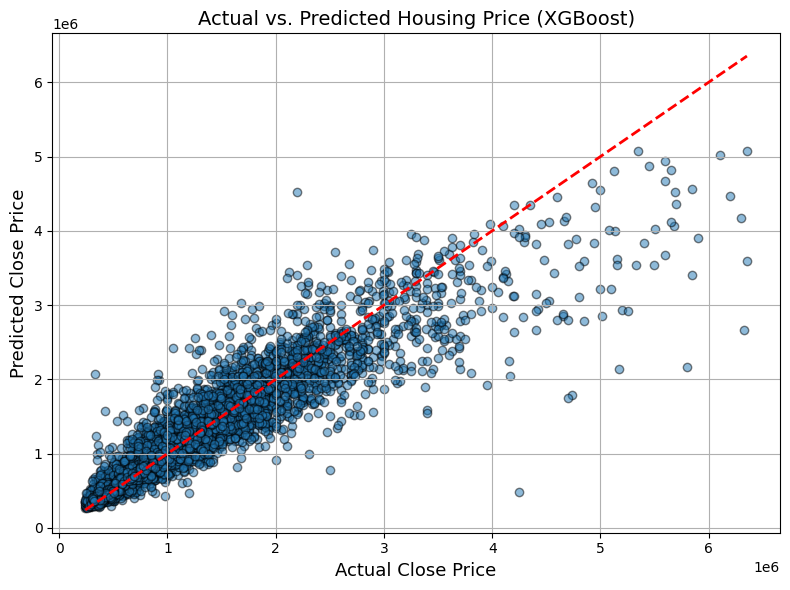

In [ ]:
# show scatterplot distribution with ideal red line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5, edgecolor='k')

# set the ideal red line
min_price = min(y_test.min(), pred_test.min())
max_price = max(y_test.max(), pred_test.max())

plt.plot([min_price, max_price],
         [min_price, max_price],
         color='red', linestyle='--', linewidth=2)


plt.title("Actual vs. Predicted Housing Price (Random Forest)", fontsize=14)
plt.xlabel("Actual Close Price", fontsize=13)
plt.ylabel("Predicted Close Price", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

- Most of observations are concentrated to the red line, especially low and mid price properties. This suggest that **model generally captures the relationship between property features and housing price reasonably well for low and mid prices**.

- However, the prediction error become larger as actual price increase.  For high price properties, many points fall below the redline. This indicates **the model trends underpredict expensive homes starting over $\$3,500,000$ actual price**.

- The points are spread out more at higher prices. This shows incrasing error variance that model is less consistent for expensive properties.

- There are also a few large outliers. Some properties are overprideicted or underpredicted.

# **Boosting Model**

We will construct boosting model of XGBoost regressor to predict the close price of California housing market sold during Dec 2024 to May 2025.

- Grid Search for hyperparameter tuning to find optimal settings for random forest regressor.

- In each stage, only one group of related parameters was tuned, while the remaining parameters were temporarily held constant at reasonable baseline values or at the best values identified in earlier stages. The best parameters from each stage were then carried forward to the next stage.

- Specifically, tree-complexity parameters were tuned first, followed by row and feature sampling parameters, the number of trees, and finally the maximum number of leaf nodes if additional regularization was needed.

- Focus on mean absolute percentage error due to close price of huge with greater than 0 values.



Let's tune the tree complexity parameters.

- **max_depth** : Maximum depth of each tree

- **min_child_weight** : Minimum amount of data needed a child node

- **gamma** : Minimum improvement required to make another split.

In [ ]:
# set XGBoost regressor model
model_xgb = XGBRegressor(
    objective = "reg:squarederror",
    tree_method = "hist",

    n_estimators=300,
    learning_rate=0.05,

    subsample=0.9,
    colsample_bytree=0.8,

    reg_alpha=0,
    reg_lambda=1,

    random_state=48,
    n_jobs=1
)

In [ ]:
# set the hyperparameter
param = {
    "max_depth": [3, 5, 10, 20],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.5]
}

In [ ]:
# set the grid search with 3 cross-validation and model
grid_1 = GridSearchCV(
    model_xgb,
    param_grid = param,
    scoring = scoring,
    refit="MAPE",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

grid_1.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    l...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.5], 'max_depth': [3, 5, 10, 20],
                         'min_child_weight': [1, 3, 5, 10]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_1.cv_results_)

cv_results = (
    cv_results[
        [
            "param_gamma",
            "param_max_depth",
            "param_min_child_weight",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_gamma,param_max_depth,param_min_child_weight,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,0.0,10,1,0.120623,257779.135691,133670.775773,0.866137,0.992100,6.400362
1,0.1,10,1,0.120623,257779.135691,133670.775773,0.866137,0.992100,6.677399
2,0.5,10,1,0.120623,257779.135691,133670.775773,0.866137,0.992100,6.378945
3,0.0,10,3,0.120937,257636.173959,133900.788789,0.866259,0.990535,5.480494
4,0.1,10,3,0.120937,257636.173959,133900.788789,0.866259,0.990535,5.158098
5,0.5,10,3,0.120937,257636.173959,133900.788789,0.866259,0.990535,5.476058
6,0.0,10,5,0.121218,256501.546864,134212.229506,0.867442,0.987049,4.500417
7,0.1,10,5,0.121218,256501.546864,134212.229506,0.867442,0.987049,4.747018
8,0.5,10,5,0.121218,256501.546864,134212.229506,0.867442,0.987049,4.358433
9,0.5,10,10,0.121660,254725.816230,134250.303611,0.869263,0.978131,3.844215


- The most important parameter is tree depth and $10$ depth tree performed better the most. Then the minimum number of child node shows better at the less amount.

- The gamma followed by tree depth and minimum number of child node, and $0$ gamma performed best in this stage.

We will check closely on max depth around 10 with consistent gamma of $0$.

In [ ]:
# set hyperparameter
param = {
    "max_depth": [8, 9, 10, 11, 12],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0]
}

In [ ]:
# set grid search with 3 cross-validation and model
grid_1 = GridSearchCV(
    model_xgb,
    param_grid = param,
    scoring = scoring,
    refit="MAPE",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

grid_1.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    l...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0], 'max_depth': [8, 9, 10, 11, 12],
                         'min_child_weight': [1, 3, 5, 10]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_1.cv_results_)

cv_results = (
    cv_results[
        [
            "param_gamma",
            "param_max_depth",
            "param_min_child_weight",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_gamma,param_max_depth,param_min_child_weight,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,0,11,3,0.120133,258773.995678,133687.383556,0.865105,0.995193,7.076189
1,0,11,1,0.120299,260800.886949,134201.719476,0.862958,0.996268,9.433530
2,0,11,5,0.120351,257167.175757,133696.771924,0.866754,0.992327,5.837352
3,0,12,10,0.120505,255940.214540,133502.417269,0.868014,0.987333,4.748568
4,0,12,5,0.120530,258476.268003,134092.543998,0.865384,0.995419,7.397411
5,0,10,1,0.120623,257779.135691,133670.775773,0.866137,0.992100,6.967528
6,0,12,1,0.120633,263981.812733,135042.473574,0.859604,0.998403,13.225060
7,0,11,10,0.120820,254547.463931,133571.547619,0.869440,0.983578,4.472549
8,0,12,3,0.120923,261076.617006,134773.106184,0.862661,0.997476,9.234702
9,0,10,3,0.120937,257636.173959,133900.788789,0.866259,0.990535,5.408064


- Based on the best MAPE, value of parameters of maximum depth of tree $11$, and number of children to control making more splits of $3$ present the best. However, it shows strongly overfit that training fit $R^2$ is $0.9952$, while validation $R^2$ test is $86.5\%$.

- Increasing depth of tree from $9$ to $11$ shows
  - MAPE, MAE improves slightly

  - RMSE and $R^2$ generally become worse

  - Training $R^2$ rises sharply



- We will use the row 7 of **max depth $11$ and min child weight $10$** with **gamma $0$**. Because the MAPE difference is only $0.0687$, and it gives slightly lower MAE and higher validation test $R^2$ score than the first top row result. Also it has smaller gap betweeen validation training and test $R^2$ with fast training. The row 7 result show **MAPE about 12.08%, MAE $\$133,571$, and test $R^2$ $86.92\%$.**

Now, let's identify sampling parameters

- **subsample** : Proportion of observation used per tree

- **colsample_bytree** : Proportion of features used per tree

In [ ]:
# set the XGBoost gressor model
model_xgb = XGBRegressor(
    objective = "reg:squarederror",
    tree_method = "hist",

    n_estimators=300,
    learning_rate=0.05,

    reg_alpha=0,
    reg_lambda=1,


    max_depth = 11,
    min_child_weight = 10,
    gamma = 0,

    random_state = 48,
    n_jobs = 1
)

In [ ]:
# set hyperparameter
param = {
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}


In [ ]:
# set the grid search with 3 cross-validation and model
grid_2 = GridSearchCV(
    model_xgb,
    param_grid = param,
    scoring = scoring,
    refit = "MAPE",
    cv = 3,
    n_jobs = -1,
    return_train_score=True

)

grid_2.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lea...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'subsample': [0.7, 0.85, 1.0]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_2.cv_results_)

cv_results = (
    cv_results[
        [
            "param_subsample",
            "param_colsample_bytree",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_subsample,param_colsample_bytree,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,1.00,0.8,0.120274,254547.163467,133360.415031,0.869464,0.983621,7.776850
1,0.85,1.0,0.120379,256146.218027,134277.015747,0.867815,0.983071,9.566476
2,0.70,1.0,0.121243,256632.664602,134776.493249,0.867301,0.978978,9.001923
3,0.85,0.8,0.121333,254696.507270,134057.326839,0.869302,0.982513,8.631803
4,1.00,0.6,0.121485,253624.545867,133509.591203,0.870363,0.984310,7.902665
5,1.00,1.0,0.121829,260267.023168,136168.602759,0.863519,0.983800,7.428667
6,0.70,0.8,0.122096,254874.810825,134572.451690,0.869109,0.978216,6.686973
7,0.85,0.6,0.123422,254695.035678,135155.610101,0.869286,0.981872,10.933645
8,0.70,0.6,0.124661,255852.109436,136176.157003,0.868091,0.977276,10.314741


- Based on best MAPE and balanced on $R^2$ and overfit, the row of 4 that **proportion of observation $100%$ and feature $60\%$** present the best in this stage.

- **The result show slightly worse than before stage on MAPE $12.18\%$. However, it has slightly better on MAE $\$133,509$ and test $R^2$ $87.04\%$.**

Now, let's identify the regularization parameters

- **reg_alpha** : L1 regularization

- **reg_lambda** : L2 regularization

In [ ]:
# set xgboost regressor model
model_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",

    n_estimators=300,
    learning_rate=0.05,

    max_depth=11,
    min_child_weight=10,
    gamma=0,

    subsample=1,
    colsample_bytree=0.6,

    random_state=48,
    n_jobs=1
)

In [ ]:
# set hyperparameter
param = {
    "reg_alpha": [0, 0.1, 1, 10, 100],
    "reg_lambda": [1, 5, 10, 50, 100]
}

In [ ]:
# set grid search with 3 validation set and model
grid_3 = GridSearchCV(
    model_xgb,
    param_grid = param,
    scoring = scoring,
    refit="MAPE",
    cv=3,
    n_jobs=-1,
    return_train_score=True

)

grid_3.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.6,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lear...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'reg_alpha': [0, 0.1, 1, 10, 100],
                         'reg_lambda': [1, 5, 10, 50, 100]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'})

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_3.cv_results_)

cv_results = (
    cv_results[
        [
            "param_reg_alpha",
            "param_reg_lambda",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_reg_alpha,param_reg_lambda,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,0.0,5,0.120988,252666.175010,133124.176690,0.871347,0.978923,6.819613
1,1.0,5,0.120988,252666.177214,133124.178431,0.871347,0.978923,7.770426
2,10.0,5,0.120989,252666.109469,133124.253850,0.871347,0.978923,7.296223
3,0.1,5,0.121005,252696.641125,133154.708102,0.871316,0.978865,8.899733
4,100.0,1,0.121306,253516.012470,133381.264755,0.870487,0.983952,8.153167
5,1.0,1,0.121313,253398.400656,133295.557730,0.870597,0.984271,7.320219
6,10.0,1,0.121402,253441.663833,133372.738560,0.870549,0.983986,7.265515
7,100.0,5,0.121405,253687.462481,133523.482796,0.870306,0.979041,7.498716
8,10.0,10,0.121456,253329.179054,133582.366037,0.870663,0.973254,7.191921
9,0.0,1,0.121485,253624.545867,133509.591203,0.870363,0.984310,8.584843


- The parameter of **reg_alpha 0 and reg_lambda 5 shows  the best** in this stage. The **MAE $\$133,124$ and test $R^2$ $87.13\%$** were slightly better, and **MAPE about 12.10%** was slightly worse then before tuning.

- The reg_lambda $5$ performed better than other values, and reg_alpha followed performed followed by reg_lambda.




Let's identify frame of the tree

- **learning_rate** : Control how quickly model learns

- **n_estimators** : Total number of trees

In [ ]:
model_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",

    max_depth=11,
    min_child_weight=10,
    gamma=0,

    subsample=1,
    colsample_bytree=0.6,

    reg_alpha=0,
    reg_lambda=5,

    random_state=48,
    n_jobs=1
)

In [ ]:
# set the hyperparameter
param = [
    {
        "learning_rate": [0.1],
        "n_estimators": [300, 500]
    },
    {
        "learning_rate": [0.05],
        "n_estimators": [300, 500, 800, 1000]
    },
    {
        "learning_rate": [0.03],
        "n_estimators": [800, 1200]
    }
]

In [ ]:
# set grid search with 3 validation set and model
grid_4 = GridSearchCV(
    model_xgb,
    param_grid=param,
    scoring=scoring,
    refit="MAPE",
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

grid_4.fit(X_train_processed, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.6,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lear...
             param_grid=[{'learning_rate': [0.1], 'n_estimators': [300, 500]},
                         {'learning_rate': [0.05],
                          'n_estimators': [300, 500, 800, 1000]},
                         {'learning_rate': [0.03],
                          'n_estimators': [800, 1200]}],
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'},
             verbose=2)

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_4.cv_results_)

cv_results = (
    cv_results[
        [
            "param_learning_rate",
            "param_n_estimators",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_learning_rate,param_n_estimators,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,0.03,1200,0.119274,251167.900197,131522.790758,0.872894,0.992004,22.340591
1,0.03,800,0.119520,251859.574809,131844.675304,0.872193,0.986621,17.596819
2,0.05,800,0.119995,250538.935733,131980.544784,0.873507,0.993488,17.371711
3,0.05,1000,0.120111,250493.812416,132008.186630,0.873553,0.995607,19.697112
4,0.05,500,0.120142,251206.977894,132243.621547,0.872830,0.987292,11.100967
5,0.05,300,0.120988,252666.175010,133124.176690,0.871347,0.978923,7.375054
6,0.10,300,0.122569,252489.141367,134282.046317,0.871545,0.989205,6.080331
7,0.10,500,0.122785,252310.639703,134290.920076,0.871726,0.995383,10.217117


- The more trees performed better on MAPE and MAE decrease as possible. However, it cause slightly more overfitting.

- The less learning rate performed the best amoung other proportion.

We will run closely around learning rate of $0.03$ and decrease the number of trees to decrease overfitting.

In [ ]:
# set the parameter for tuning
param = {
    "learning_rate": [0.03, 0.04, 0.05, 0.06],
    "n_estimators": [500, 700, 900, 1100]
}

In [ ]:
# set the grid search with validation set 3 including xgboost regressor
grid_4 = GridSearchCV(
    model_xgb,
    param_grid=param,
    scoring=scoring,
    refit="MAPE",
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

grid_4.fit(X_train_processed, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.6,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lear...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.04, 0.05, 0.06],
                         'n_estimators': [500, 700, 900, 1100]},
             refit='MAPE', return_train_score=True,
             scoring={'MAE': 'neg_mean_absolute_error',
                      'MAPE': 'neg_mean_absolute_percentage_error', 'R2': 'r2',
                      'RMSE': 'neg_root_mean_squared_error'},
             verbose=2)

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_4.cv_results_)

cv_results = (
    cv_results[
        [
            "param_learning_rate",
            "param_n_estimators",
            "mean_test_MAPE",
            "mean_test_RMSE",
            "mean_test_MAE",
            "mean_test_R2",
            "mean_train_R2",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_MAPE", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_MAPE",
    "mean_test_RMSE",
    "mean_test_MAE"
]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_learning_rate,param_n_estimators,mean_test_MAPE,mean_test_RMSE,mean_test_MAE,mean_test_R2,mean_train_R2,mean_fit_time
0,0.03,1100,0.118622,250081.957061,130916.050647,0.873991,0.990915,19.927100
1,0.03,900,0.118765,250374.786164,131085.021623,0.873697,0.988120,17.312986
2,0.04,900,0.118974,250702.019466,131149.262994,0.873363,0.991958,16.502509
3,0.04,1100,0.118987,250497.303067,131089.236693,0.873571,0.994158,19.791837
4,0.04,700,0.119028,250999.126824,131296.229839,0.873059,0.988759,13.544206
5,0.03,700,0.119059,250945.553834,131426.230763,0.873121,0.984238,14.338098
6,0.04,500,0.119469,251784.129503,131764.614213,0.872259,0.983650,9.825369
7,0.05,700,0.119750,250664.542943,131860.070310,0.873401,0.991711,13.142969
8,0.05,900,0.119761,250423.357550,131796.386360,0.873643,0.994494,17.071039
9,0.05,500,0.119870,251219.396016,132078.373864,0.872840,0.987071,10.046737


- Most of the good performance revealed on learning rate $0.03$ and $0.04$.

- If we consider the balance among MAPE, MAE, and overfit, the best parameters are **learning rate $0.04$ and $500$ trees** performed the best in this stage. The **MAPE $12\%$, MAE $\$131,764$, validation test $R^2$ $87.23\%$, and slightly overfit about $11.19\%$** from training $R^2$ $98.42\%$.

## Evaluation

In [ ]:
# create final model of xgboost regressor
model_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",

    max_depth=11,
    min_child_weight=10,
    gamma=0,

    subsample=1,
    colsample_bytree=0.6,

    reg_alpha=0,
    reg_lambda=5,

    n_estimators = 500,
    learning_rate = 0.04,

    random_state=48,
    n_jobs=1
)


model_xgb.fit(X_train_processed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=11,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=1, num_parallel_tree=None, ...)

In [ ]:
# predict close price from training and test set
pred_train2 = model_xgb.predict(X_train_processed)

pred_test2 = model_xgb.predict(X_test_processed)

# show the results of MAPE, MAE, RMSE, and R^2
print(f"Test MAPE:, {mean_absolute_percentage_error(y_test, pred_test2)}")
print(f"Test RMSE:, ${root_mean_squared_error(y_test, pred_test2)}")
print(f"Test MAE:, ${mean_absolute_error(y_test, pred_test2)}")
print(f"Test R^2_test:, {r2_score(y_test, pred_test2)}")
print(f"Test R^2_train:, {r2_score(y_train, pred_train2)}")



Test MAPE:, 0.1151447269266667
Test RMSE:, $245917.9813230277
Test MAE:, $129701.16436987382
Test R^2_test:, 0.8857548006505451
Test R^2_train:, 0.9807053918036717


- The final XGBoost model achieved a test MAPE, **predicted property prices differed from actual sale prices by approximately $11.51\%$ on average**.

- The MAE, **predicted prices were off by approximately $\$129,701$ on average**.

- The **RMSE is $\$245,917$** and it is higher than the MAE because it gives greater weight to large prediction errors. This difference suggests that **some properties had large prediction errors**.

- The model has test $R^2$, **explaining approximately 88.57% of the variation in property prices amoong unseen observations.**

- The gaps between training $98.07%$ and test $88.57%$ $R^2$ is 9.5\% **indicates small-mediate overfitting. However, the strong test performance suggests that final model still generalizes well to unseen properties.**

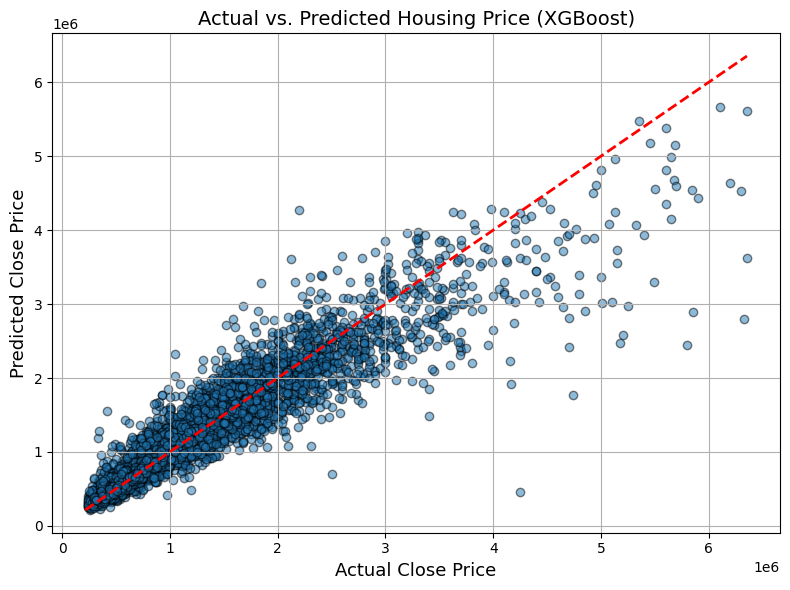

In [ ]:
# show scatterplot for distribution actual vs. predicted price
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test2, alpha=0.5, edgecolor='k')

# show the ideal red line for prediction
min_price = min(y_test.min(), pred_test2.min())
max_price = max(y_test.max(), pred_test2.max())


plt.plot([min_price, max_price],
         [min_price, max_price],
         color='red', linestyle='--', linewidth=2)

plt.title("Actual vs. Predicted Housing Price (XGBoost)", fontsize=14)
plt.xlabel("Actual Close Price", fontsize=13)
plt.ylabel("Predicted Close Price", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

- The most predicted values are close to the diagonal reference line, **suggesting generally strong predictive performance. The low to mid property prices below $4 million clustered around the red line**.

- Above $4 million, **the more actual price increase, the prediction of price tends to underpredict prices at upper end market** falling down from red line. Serveral large errors are showing why RMSE is higher than MAE.


# **Quantile XGBoost Regressor**

We will construct a multi-quantile XGBoost regressor to estimate the distribution of close price for California properties sold from December 2024 to May 2025.

-  Unlike the standard XGBoost regression model estimating expected price, the **quantile model predicts the median and 90% prediction interval using 5th, 50th, 90th percentiles of closing price.** Then with three losses will be averaged to produce one overall multi-quantile score

- Grid search with three fold cros-vlidation to identify optimal hyperparameter for quantile XGBoost regressor just like previous XGBoost Regressor. We cannot use the same hyper parameter from previous best XGBoost because we will run the quantile model measuring **qunatile error**, not **squared error**.

- Model selection depends on mean pinball loss because it is designed to evaluate quantile predictions

We will use pinball loss to measure uncertainty range of prediction in lower, median, and upper quantile within 90% percentile, using penalization in each overpredction and underprediction.

- Over prediction, upper quantile penalize less and lower quantile penalize high.

- under prediction, upper quantile penalize high, lower prediction penalize less.

- median prediction will act like predicting mean absolute error (MAE).

We will set the scoring those pinball losses using mean losses to measure all three at the same time, finding less pinball loss score.

In [ ]:
# set 90% interval including median
quantiles = np.array([0.05, 0.50, 0.95])

# function for pinball loss with average three losses
def multi_quantile_pinball_loss(y_true, y_pred):

    losses = []

    for i, alpha in enumerate(quantiles):
        quantile_loss = mean_pinball_loss(
            y_true,
            y_pred[:, i],
            alpha=alpha
        )
        losses.append(quantile_loss)

    return np.mean(losses)


# set the pinball loss score for grid search
multi_quantile_scorer = make_scorer(
    multi_quantile_pinball_loss,
    greater_is_better=False
)

Let's tune the tree complexity parameters.

- **max_depth** : Maximum depth of each tree

- **min_child_weight** : Minimum amount of data needed a child node

- **gamma** : Minimum improvement required to make another split.

In [ ]:
# set the quantile xgboost regressor
model_xgb_quantile = XGBRegressor(
    objective = "reg:quantileerror",
    quantile_alpha=quantiles,
    tree_method = "hist",

    n_estimators=300,
    learning_rate=0.05,

    subsample=0.9,
    colsample_bytree=0.8,

    reg_alpha=0,
    reg_lambda=1,

    random_state=48,
    n_jobs=1
)


In [ ]:
# set the parameter
param = {
    "max_depth": [3, 5, 10, 20],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.5]
}

In [ ]:
# set the grid search with 3 cross-validation and xgboost quantile
grid_1 = GridSearchCV(
    model_xgb_quantile,
    param_grid = param,
    scoring = multi_quantile_scorer,
    cv=3,
    refit = "pinball",
    n_jobs=-1,
    return_train_score=True
)

grid_1.fit(X_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    l...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.5], 'max_depth': [3, 5, 10, 20],
                         'min_child_weight': [1, 3, 5, 10]},
             refit='pinball', return_train_score=True,
             scoring=make_scorer(multi_quantile_pinball_loss, greater_is_better=False, response_method='predict'))

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_1.cv_results_)

cv_results = (
    cv_results[
        [
            "param_max_depth",
            "param_min_child_weight",
            "param_gamma",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_score",
    "mean_train_score",

]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_max_depth,param_min_child_weight,param_gamma,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time
0,10,10,0.1,38847.651330,182.107379,23550.260653,75.496089,25.071396
1,20,10,0.5,38997.532911,73.584764,21110.552801,101.354569,36.227487
2,10,10,0.0,39067.706521,188.719889,23161.921558,84.562427,26.768985
3,10,10,0.5,39089.860587,113.336145,27272.815982,170.963577,19.009604
4,10,5,0.5,39468.291389,130.883250,26159.471656,173.986612,20.102406
5,20,10,0.1,39630.256917,200.620117,16132.593641,65.138618,55.805051
6,10,5,0.1,39655.733399,226.391496,22346.704149,178.027516,26.778798
7,10,5,0.0,39764.278192,253.988148,22138.472938,148.032689,28.489111
8,20,5,0.5,39765.436553,156.722074,18157.531615,150.684108,47.839766
9,10,3,0.5,39969.623576,269.569576,25808.198406,250.344972,21.390865


- The maximum depth of tree has good performance between $10$ and $20$ with minimum child of $5$ or $10$ weight.

- **The best parameter values are maximum depth of $10$, minimum child weight $10$, and gamma $0.5$, row 3**. The row 0 seems the best, but row 3 has less overfit, less standard deviation, less time, and it has only difference of $\$242$ validation loss and $0.62\%$ worse.

- T**he best parameters present validation set test score $39,089$ and training score $27,272$**. We can pick the first 0 and 1 row as best parameters, however, row 3 has **less overfit $11,817$** and balanced score of std test score.


Now, let's identify sampling parameters

**subsample** : Proportion of observation used per tree

**colsample_bytree** : Proportion of features used per tree

In [ ]:
# set the quantile xgboost regressor
model_xgb_quantile = XGBRegressor(
    objective = "reg:quantileerror",
    quantile_alpha=quantiles,
    tree_method = "hist",

    n_estimators=300,
    learning_rate=0.05,

    reg_alpha=0,
    reg_lambda=1,


    max_depth = 10,
    min_child_weight = 10,
    gamma = 0.5,

    random_state = 48,
    n_jobs = 1
)

In [ ]:
# set hyperparameter
param = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0]
}


In [ ]:
# set the grid search with 3 cross-validation and model
grid_2 = GridSearchCV(
    model_xgb_quantile,
    param_grid = param,
    scoring = multi_quantile_scorer,
    cv = 3,
    refit = "pinball",
    n_jobs = -1,
    return_train_score=True

)

grid_2.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0.5, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    l...
                                    min_child_weight=10, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 0.9, 1.0],
                         'subsample': [0.7, 0.8, 0.9, 1.0]},
             refit='pinball', return_train_score=True,
             scoring=make_scorer(multi_quantile_pinball_loss, greater_is_better=False, response_method='predict'))

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_2.cv_results_)

cv_results = (
    cv_results[
        [
            "param_subsample",
            "param_colsample_bytree",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_score",
    "mean_train_score",

]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_subsample,param_colsample_bytree,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time
0,0.8,0.9,38967.906274,204.896204,27338.183945,136.953046,13.767893
1,0.7,0.9,39034.851573,157.875118,28066.859384,99.738473,12.702291
2,0.9,0.9,39088.162008,244.707935,27090.285246,74.943430,13.760958
3,0.9,0.8,39089.860587,113.336145,27272.815982,170.963577,13.733352
4,0.8,0.8,39090.677879,113.276656,27743.403995,35.390998,13.390397
5,0.8,1.0,39139.363189,50.682250,27369.065491,105.988481,13.698438
6,0.7,0.8,39201.061104,204.497053,28270.775727,145.320451,12.274168
7,0.9,1.0,39233.241889,103.180015,26903.615340,40.950188,14.433006
8,0.7,1.0,39283.062489,279.360107,28026.024527,62.472246,13.078817
9,1.0,0.9,39303.872327,256.535964,27053.411521,95.088565,14.305141


In this stage the best values are:

- **The subsample of 0.8 and colsample_bytree of 0.8** is the best decision because it has best balance considering  overfit, test score, and std score as well.

- **The validation test score is similar as previous of $39,090$, and standard deviation test $113.28$, and overfit $11,347$**.

Now, let's identify the regularization parameters

- **reg_alpha** : L1 regularization

- **reg_lambda** : L2 regularization

In [ ]:
# set the quantile xgboost regressor
model_xgb_quantile = XGBRegressor(
    objective = "reg:quantileerror",
    quantile_alpha=quantiles,
    tree_method = "hist",

    n_estimators=300,
    learning_rate=0.05,

    subsample = 0.8,
    colsample_bytree = 0.8,


    max_depth = 10,
    min_child_weight = 10,
    gamma = 0.5,

    random_state = 48,
    n_jobs = 1
)

In [ ]:
# set hyperparameter
param = {
    "reg_alpha": [0, 0.1, 1, 10, 25],
    "reg_lambda": [0, 0.1, 1, 10, 25]
}

In [ ]:
# set the grid search with 3 cross-validation and model
grid_3 = GridSearchCV(
    model_xgb_quantile,
    param_grid = param,
    scoring = multi_quantile_scorer,
    cv = 3,
    refit = "pinball",
    n_jobs = -1,
    return_train_score=True

)

grid_3.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0.5, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    le...
                                    min_child_weight=10, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=300,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'reg_alpha': [0, 0.1, 1, 10, 25],
                         'reg_lambda': [0, 0.1, 1, 10, 25]},
             refit='pinball', return_train_score=True,
             scoring=make_scorer(multi_quantile_pinball_loss, greater_is_better=False, response_method='predict'))

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_3.cv_results_)

cv_results = (
    cv_results[
        [
            "param_reg_alpha",
            "param_reg_lambda",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_score",
    "mean_train_score",

]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_reg_alpha,param_reg_lambda,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time
0,0.1,0.1,38938.030146,268.284144,27663.662266,41.631782,13.268966
1,0.1,10.0,38965.846960,95.437457,29128.017959,171.886456,16.033199
2,1.0,0.0,39012.175705,228.441886,28779.938998,107.956019,14.620940
3,0.1,0.0,39036.698316,102.230745,27671.335248,75.866204,13.191618
4,0.0,0.0,39048.778682,155.731721,27667.870672,91.575806,13.757171
5,0.0,0.1,39050.052779,124.101043,27643.441490,36.073638,18.668623
6,0.0,10.0,39086.632155,115.401517,29071.264802,96.029660,15.098451
7,0.0,1.0,39090.677879,113.276656,27743.403995,35.390998,15.968801
8,1.0,0.1,39092.802083,150.501942,28841.395781,131.956650,13.771461
9,0.1,1.0,39094.948777,173.371453,27843.365365,171.650655,18.253554


The best values in this stage:

- The less alpha regularization, the better performance shows, and lambda depends on alpha values.

- **reg_alpha $0.1$ and reg_lambda $10.0$** are the best decision because it has the best balance of **validation test $38,965$, test standard deviation $95.44$, less overfit $9,837$**.


Let's identify frame of the tree

- **learning_rate** : Control how quickly model learns

- **n_estimators** : Total number of trees

In [ ]:
# set the quantile xgboost regressor
model_xgb_quantile = XGBRegressor(
    objective = "reg:quantileerror",
    quantile_alpha=quantiles,
    tree_method = "hist",

    max_depth = 10,
    min_child_weight = 10,
    gamma = 0.5,

    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 10,

    random_state = 48,
    n_jobs = 1
)

In [ ]:
# set the hyperparameter
param = [
    {
        "learning_rate": [0.1],
        "n_estimators": [300, 500]
    },
    {
        "learning_rate": [0.05],
        "n_estimators": [300, 500, 800, 1000]
    },
    {
        "learning_rate": [0.03],
        "n_estimators": [800, 1200]
    }
]

In [ ]:
# set the grid search with 3 cross-validation and model
grid_4 = GridSearchCV(
    model_xgb_quantile,
    param_grid = param,
    scoring = multi_quantile_scorer,
    cv = 3,
    refit = "pinball",
    n_jobs = -1,
    return_train_score=True

)

grid_4.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=0.5, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    le...
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid=[{'learning_rate': [0.1], 'n_estimators': [300, 500]},
                         {'learning_rate': [0.05],
                          'n_estimators': [300, 500, 800, 1000]},
                         {'learning_rate': [0.03],
                          'n_estimators': [800, 1200]}],
             refit='pinball', return_train_score=True,
             scoring=make_scorer(multi_quantile_pinball_loss, greater_is_better=False, response_method='predict'))

In [ ]:
# show result of performance on hyperparameter tuning
cv_results = pd.DataFrame(grid_4.cv_results_)

cv_results = (
    cv_results[
        [
            "param_learning_rate",
            "param_n_estimators",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time"
        ]
    ].sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)
)

# convert negative values into positive
neg_metrics = [
    "mean_test_score",
    "mean_train_score",

]

cv_results[neg_metrics] = cv_results[neg_metrics].abs()
cv_results

,param_learning_rate,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time
0,0.03,1200,38074.544765,160.997487,26247.990598,165.480181,49.775152
1,0.05,1000,38118.701327,99.369901,25674.107352,96.710855,40.895343
2,0.05,800,38213.548194,97.648430,26214.402727,88.892111,32.306647
3,0.03,800,38344.949501,158.336738,27375.917083,84.116533,35.673540
4,0.05,500,38502.290878,100.701797,27488.738314,145.600823,20.463986
5,0.10,500,38826.603637,59.830006,25873.197339,140.531764,19.202777
6,0.05,300,38965.846960,95.437457,29128.017959,171.886456,13.806872
7,0.10,300,39073.345425,60.169867,27197.389111,116.226996,16.558432


The best values in this stage:

- The less learning rate with more trees tends to perform well with scoring less pinball loss.

- **learning_rate $0.05$ and n_estimator of $1000$.** It has best balance of **validation test score $38,074$ loss, standard deviation test $99.37$, and less overfit $12,444$** loss.

Let's combine all the combination we found the best parameter values in quantile Xgboost regressor.

## Evaluation

In [ ]:
# set the quantile xgboost regressor
model_xgb_quantile = XGBRegressor(
    objective = "reg:quantileerror",
    quantile_alpha=quantiles,
    tree_method = "hist",

    max_depth = 10,
    min_child_weight = 10,
    gamma = 0.5,

    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 10,

    learning_rate = 0.05,
    n_estimators = 1000,

    random_state = 48,
    n_jobs = 1
)

model_xgb_quantile.fit(X_train_processed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=1, num_parallel_tree=None, ...)

In [ ]:
pred_quantile = model_xgb_quantile.predict(X_test_processed)
pred_quantile

array([[ 500470.25,  611489.75,  666086.7 ],
       [ 680912.7 ,  814549.2 , 1007109.  ],
       [ 533803.94,  571139.9 ,  749373.25],
       ...,
       [ 783398.7 , 1502523.  , 2144013.2 ],
       [ 752996.25,  888746.44, 1366360.5 ],
       [ 858812.5 , 1706830.  , 2043886.5 ]], dtype=float32)

In [ ]:
pred_lower = pred_quantile[:, 0]
pred_median = pred_quantile[:, 1]
pred_upper = pred_quantile[:, 2]

pinball_lower = mean_pinball_loss(y_test, pred_lower, alpha = 0.05)
pinball_median = mean_pinball_loss(y_test, pred_median, alpha = 0.5)
pinball_upper = mean_pinball_loss(y_test, pred_upper, alpha = 0.95)

mean_pinball =np.mean(
    [
        pinball_lower,
        pinball_median,
        pinball_upper
    ]
)

coverage = np.mean(
    (y_test >= pred_lower)
    &
    (y_test <= pred_upper)
)

avg_interval_width = np.mean(pred_upper - pred_lower)

print(f"5% pinball loss: ${pinball_lower:,.2f}")
print(f"50% pinball loss: ${pinball_median:,.2f}")
print(f"95% pinball loss: ${pinball_upper:,.2f}")
print(f"Mean pinball loss: ${mean_pinball:,.2f}")
print("90% coverage:", coverage)
print(f"Average interval width: ${avg_interval_width:,.2f}")


5% pinball loss: $19,822.13
50% pinball loss: $64,296.96
95% pinball loss: $28,366.77
Mean pinball loss: $37,495.29
90% coverage: 0.8636172450052576
Average interval width: $629,221.31


- Evaluated pinball loss that measures how accurately it estimates different parts of the expected price range, the lower values indicate better predictions. **The combined average pinball loss was approximately $\$37,495$ and was primarily used to compare and tune different versions of the model.**


- **The 5th, 50th, and 95th percentile models produced pinball losses of approximately $\$19,822$, $\$64,297$, and $\$28,367$, respectively**. These values are evaluation losses as average weighted error, rather than predicted home prices, and lower values indicate better quantile prediction performance. The average pinball loss across the three quantiles was approximately $\$37,495$.

- **coverage of the $90\%$ interval was approximately $86.36\%$**. **This means that about 86 out of every 100 actual sale prices fell within the model’s predicted interval, slightly below intended $90\%$**.

- **The average prediction-interval width was approximately $\$629,221$**. Although the model achieved coverage close to the desired level, the intervals were relatively wide. **This shows substantial uncertainty in California property sold price predictions**.

- Overall, model provides useful range around its median price estimates, although the lower than target coverage suggests that the prediction intervals may be too narrow or require further calibration.

In [ ]:
print("\nMedian predictions")
print(f"5%:  ${np.median(pred_lower):,.2f}")
print(f"50%: ${np.median(pred_median):,.2f}")
print(f"95%: ${np.median(pred_upper):,.2f}")


Median predictions
5%:  $684,337.00
50%: $850,977.81
95%: $1,108,420.38


Across the test set, the median predicted 5th-percentile price was approximately $\$684,337$, the median 50th-percentile prediction was \$$850,978$, and the median predicted 95th-percentile price was $\$1,108,420$. These results indicate that the model generally produced a wider range above the median prediction, reflecting greater uncertainty toward higher housing prices.

In [ ]:
pred_train =  model_xgb_quantile.predict(X_train_processed)

pred_median_train = pred_train[:, 1]

mae = mean_absolute_error(y_test, pred_median)
mape = mean_absolute_percentage_error(y_test, pred_median)
rmse = root_mean_squared_error(y_test, pred_median)
r2_test = r2_score(y_test, pred_median)
r2_train = r2_score(y_train, pred_median_train)

print(f"Mediean MAE: ${mae:,.2f}")
print("Median MAPE:", mape)
print(f"Median RMSE: ${rmse:,.2f}")
print("Median test R²:", r2_test)
print("Median train R²:", r2_train)

Mediean MAE: $128,593.92
Median MAPE: 0.10923876298772843
Median RMSE: $256,988.90
Median test R²: 0.8752369077548838
Median train R²: 0.9237937701058733


The median prediction from quantile xgboost model achieved

- **On average sold properties, the predicted meidan sale price differs from the actual sale price by about $\$128,593$**.

- **On average sold properties, the predicted median sale prices differed from actual prices by about $10.9\%$**.

- **The RMSE $\$256,988$ is twice more higher than MAE $\$128,593$, suggesting that some properties experienced particularly large predition errors**.

- The mdoel explained $87.5\%$ of sale price variation on test set, comparing with $92.5\%$ from training set. **The $5\%$ difference indicates small overfitting and generally acceptable generalization.**

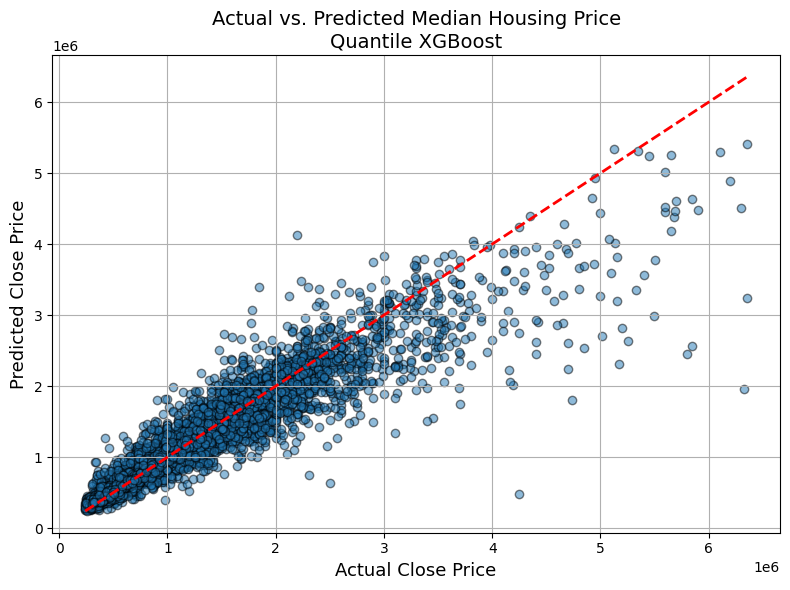

In [ ]:
plt.figure(figsize=(8, 6))

min_price = min(y_test.min(), pred_median.min())
max_price = max(y_test.max(), pred_median.max())

plt.scatter(y_test, pred_median, alpha=0.5, edgecolor='k')
plt.plot([min_price, max_price],
         [min_price, max_price],
         color='red', linestyle='--', linewidth=2)

plt.title("Actual vs. Predicted Median Housing Price\nQuantile XGBoost", fontsize=14)
plt.xlabel("Actual Close Price", fontsize=13)
plt.ylabel("Predicted Close Price", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

Quantile XGBoost median predictions generally follow the ideal prediction line, particularly for lower- and mid-priced properties.

- **Properties below about $\$3 million$**, follow the red line fairly closely, **indicating predictions generally follow the ideal prediction line, particularly for lower- and mid-priced properties.**

- **Above roughly $\$4–6$ million** fall below the red line, indicating **prediction errors become larger for higher-priced homes, and the model tends to underpredict some of the most expensive properties**.

# **Summary**
Three tree-based regression approaches were developed to predict California property closing prices: Random Forest, standard XGBoost, and Quantile XGBoost.

- The best final XGBoost model performed for single sold price prediction, with approximately $11.5\%$ MAPE, $\$129,701$ MAE, and test $R^2$ of $88.6\%$.

- Follow by best XGBoost model, its quantile model median prediction achieved similar performance, with approximately $10.9%$ MAPE, $\$128,594$ MAE, and test $R^2$ of $87.5\%$. The quantile model's intended $90\%$ interval contained approximately 86.4% of actual sale prices, with an average interval width of about $\$629,221$.




# **Main Takeaway**

- The models predict lower- and mid-priced properties relatively well, but uncertainty increases substantially for expensive properties.  

- Feature importance analysis suggests that living area, latitude, bathroom count, and longitude were among the strongest predictors, showing the importance of both physical property characteristics and location.

- The standard XGBoost model was the strongest option when the goal was to predict one expected closing price. Quantile XGBoost was more informative when the goal was to communicate uncertainty, since it gave buyers or analysts a lower estimate, median estimate, and upper estimate instead of presenting one number as certain.



# **Limitation**

- **Due to computational cost, 3-fold cross-validation was used instead of 5-fold cross-validation.** While 5 folds may provide a more stable performance estimate, it would require considerably more training time. Therefore, 3 folds were chosen as a practical compromise.

- **High-priced properties are harder to predict.** All of the models show larger errors as actual property prices increase. Expensive properties are often underpredicted, and these large errors contribute to RMSE being substantially higher than MAE.

- **Some overfitting remains.** The standard XGBoost model has training $R2$ around $98.1\%$ compared with test $R$2 around $88.6\%$. Random Forest shows an even larger train-test difference. Therefore, the models capture some training-specific patterns that do not generalize completely to unseen homes.

- **Quantile intervals are not perfectly calibrated.** The nominal $90\%$ Quantile XGBoost interval contained only about $86.4\%$ of actual sale prices. Therefore, the model provides useful uncertainty estimates, but the intervals do not yet achieve the intended coverage level.

- **Prediction intervals are relatively wide.** The average interval width of approximately $\$629,221$ indicates considerable uncertainty. For buyers, this means the model is more useful as a range of plausible values than as a precise valuation tool.

- The model is limited to the available predictors. The model uses property characteristics, location, nearby schools, and selected economic variables. Factors are not represented in the dataset such as neighborhood, crime rates, seller motivation, or not enough unusual luxury features.

- **The analysis represents a specific time period and market.**
 California properties sold from approximately December 2024 through May 2025, so the relationships learned during this market period may change as mortgage rates, inventory, demand, and broader economic conditions change.



# **Future Work**

- **Separate models by price segment**, such as typical-market versus high-priced properties, since the current models have greater difficulty at the upper end.

- **Calibrate the Quantile XGBoost intervals** so that a nominal 90% interval actually contains closer to 90% of future sale prices.

- **Add more detailed geographic variables**, such as ZIP code, city, neighborhood, school district, or distance to important amenities

- Compare additional uncertainty methods such as conformal prediction, which could provide prediction intervals with stronger coverage guarantees.

- Upgrade computational tools, using five or more splits in future work could provide greater confidence that the model performs consistently on different groups of homes.